In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym

In [3]:
print("Gymnasium version:", gym.__version__)
print("Gymnasium is installed and configured successfully.")

Gymnasium version: 1.3.0
Gymnasium is installed and configured successfully.


In [4]:
env = gym.make("CartPole-v1")
observation, info = env.reset()
print("Initial Observation:")
print(observation)

Initial Observation:
[ 0.03189025 -0.04644423 -0.03729961  0.02207889]


In [6]:
print("Observation Space:", env.observation_space)
print("Action Space:", env.action_space)
print("Number of Actions:", env.action_space.n)

Observation Space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action Space: Discrete(2)
Number of Actions: 2


In [7]:
observation, info = env.reset()
print("Initial State:", observation)
for step in range(5):
    action = env.action_space.sample()
    next_observation, reward, terminated, truncated, info = env.step(action)
    print("\nStep:", step + 1)
    print("Action:", action)
    print("Reward:", reward)
    print("Next State:", next_observation)
    print("Terminated:", terminated)
    print("Truncated:", truncated)
    if terminated or truncated:
        break
    observation = next_observation

Initial State: [-0.04480526  0.01618014 -0.02706735  0.02345421]

Step: 1
Action: 1
Reward: 1.0
Next State: [-0.04448166  0.2116796  -0.02659827 -0.2776444 ]
Terminated: False
Truncated: False

Step: 2
Action: 1
Reward: 1.0
Next State: [-0.04024806  0.4071707  -0.03215116 -0.5785963 ]
Terminated: False
Truncated: False

Step: 3
Action: 0
Reward: 1.0
Next State: [-0.03210465  0.21251374 -0.04372308 -0.29621258]
Terminated: False
Truncated: False

Step: 4
Action: 1
Reward: 1.0
Next State: [-0.02785438  0.40823084 -0.04964733 -0.60235816]
Terminated: False
Truncated: False

Step: 5
Action: 1
Reward: 1.0
Next State: [-0.01968976  0.6040108  -0.0616945  -0.91025656]
Terminated: False
Truncated: False


In [8]:
env.close()

In [9]:
env = gym.make("FrozenLake-v1", is_slippery=False)
state, info = env.reset()
print("Initial State:", state)
total_reward = 0
for step in range(20):
    action = env.action_space.sample()
    next_state, reward, terminated, truncated, info = env.step(action)
    print(
        f"Step: {step + 1}, "
        f"Action: {action}, "
        f"State: {next_state}, "
        f"Reward: {reward}"
    )
    total_reward += reward
    state = next_state
    if terminated or truncated:
        print("\nEpisode finished.")
        break
print("Total Reward:", total_reward)

Initial State: 0
Step: 1, Action: 1, State: 4, Reward: 0
Step: 2, Action: 1, State: 8, Reward: 0
Step: 3, Action: 3, State: 4, Reward: 0
Step: 4, Action: 3, State: 0, Reward: 0
Step: 5, Action: 3, State: 0, Reward: 0
Step: 6, Action: 2, State: 1, Reward: 0
Step: 7, Action: 1, State: 5, Reward: 0

Episode finished.
Total Reward: 0


In [10]:
q_table = np.zeros((env.observation_space.n, env.action_space.n))
alpha = 0.8
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01
episodes = 10000
for episode in range(episodes):
    state, _ = env.reset()
    done = False
    while not done:
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        q_table[state, action] += alpha * (
            reward + gamma * np.max(q_table[next_state]) - q_table[state, action]
        )
        state = next_state
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

print("Q-Learning completed.")

Q-Learning completed.


In [11]:
q_table_df = pd.DataFrame(
    q_table,
    columns=["Left", "Down", "Right", "Up"]
)
print(q_table_df)

        Left      Down     Right        Up
0   0.735092  0.773781  0.773781  0.735092
1   0.735092  0.000000  0.814506  0.773781
2   0.773781  0.857375  0.773781  0.814506
3   0.814506  0.000000  0.667617  0.773753
4   0.773781  0.814506  0.000000  0.735092
5   0.000000  0.000000  0.000000  0.000000
6   0.000000  0.902500  0.000000  0.814506
7   0.000000  0.000000  0.000000  0.000000
8   0.814506  0.000000  0.857375  0.773781
9   0.814506  0.902500  0.902500  0.000000
10  0.857375  0.950000  0.000000  0.857375
11  0.000000  0.000000  0.000000  0.000000
12  0.000000  0.000000  0.000000  0.000000
13  0.000000  0.902500  0.950000  0.857375
14  0.902500  0.950000  1.000000  0.902500
15  0.000000  0.000000  0.000000  0.000000


In [12]:
success = 0
test_episodes = 1000
for episode in range(test_episodes):
    state, _ = env.reset()
    done = False
    while not done:
        action = np.argmax(q_table[state])
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        state = next_state
        if reward == 1:
            success += 1

print("Success Rate:", (success / test_episodes) * 100, "%")

Success Rate: 100.0 %


In [13]:
actions = ["Left", "Down", "Right", "Up"]

for state in range(env.observation_space.n):
    best_action = actions[np.argmax(q_table[state])]
    print("State", state, "->", best_action)

State 0 -> Down
State 1 -> Right
State 2 -> Down
State 3 -> Left
State 4 -> Down
State 5 -> Left
State 6 -> Down
State 7 -> Left
State 8 -> Right
State 9 -> Down
State 10 -> Down
State 11 -> Left
State 12 -> Left
State 13 -> Right
State 14 -> Right
State 15 -> Left


In [14]:
state, _ = env.reset()
done = False
total_reward = 0

while not done:
    action = np.argmax(q_table[state])
    next_state, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward
    state = next_state
    done = terminated or truncated
print("Total Reward:", total_reward)
print("Final State:", state)

Total Reward: 1
Final State: 15


In [15]:
policy = np.argmax(q_table, axis=1)
for state, action in enumerate(policy):
    print("State", state, "->", actions[action])

State 0 -> Down
State 1 -> Right
State 2 -> Down
State 3 -> Left
State 4 -> Down
State 5 -> Left
State 6 -> Down
State 7 -> Left
State 8 -> Right
State 9 -> Down
State 10 -> Down
State 11 -> Left
State 12 -> Left
State 13 -> Right
State 14 -> Right
State 15 -> Left


In [16]:
for episode in range(10):
    state, _ = env.reset()
    done = False
    total_reward = 0
    while not done:
        action = np.argmax(q_table[state])
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        state = next_state
        total_reward += reward
    print("Episode", episode + 1, "Reward:", total_reward)

Episode 1 Reward: 1
Episode 2 Reward: 1
Episode 3 Reward: 1
Episode 4 Reward: 1
Episode 5 Reward: 1
Episode 6 Reward: 1
Episode 7 Reward: 1
Episode 8 Reward: 1
Episode 9 Reward: 1
Episode 10 Reward: 1


In [17]:
rewards = []
for episode in range(100):
    state, _ = env.reset()
    done = False
    total_reward = 0
    while not done:
        action = np.argmax(q_table[state])
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        state = next_state
        total_reward += reward
    rewards.append(total_reward)
print("Average Reward:", np.mean(rewards))

Average Reward: 1.0


In [18]:
successful_episodes = sum(rewards)
print("Successful Episodes:", int(successful_episodes))
print("Total Episodes:", len(rewards))

Successful Episodes: 100
Total Episodes: 100


In [19]:
policy_grid = np.array([actions[action][0] for action in policy]).reshape(4, 4)
print(policy_grid)

[['D' 'R' 'D' 'L']
 ['D' 'L' 'D' 'L']
 ['R' 'D' 'D' 'L']
 ['L' 'R' 'R' 'L']]


In [20]:
random_success = 0
q_success = 0
for episode in range(1000):
    state, _ = env.reset()
    done = False
    while not done:
        action = env.action_space.sample()
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
    random_success += reward
for episode in range(1000):
    state, _ = env.reset()
    done = False
    while not done:
        action = np.argmax(q_table[state])
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
    q_success += reward
print("Random Agent Success Rate:", random_success / 10, "%")
print("Q-Learning Success Rate:", q_success / 10, "%")

Random Agent Success Rate: 2.0 %
Q-Learning Success Rate: 100.0 %


In [21]:
state, _ = env.reset()
path = [state]
done = False
while not done:
    action = np.argmax(q_table[state])
    state, reward, terminated, truncated, _ = env.step(action)
    path.append(state)
    done = terminated or truncated
print("Path:", path)
print("Reward:", reward)

Path: [0, 4, 8, 9, 13, 14, 15]
Reward: 1


In [22]:
print("Number of Steps:", len(path) - 1)

Number of Steps: 6


In [26]:
learning_rates = [0.1, 0.5, 0.8, 1.0]
results = {}
for lr in learning_rates:
    q = np.zeros((env.observation_space.n, env.action_space.n))
    for episode in range(5000):
        state, _ = env.reset()
        done = False
        while not done:
            action = env.action_space.sample() if np.random.rand() < 0.1 else np.argmax(q[state])
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            q[state, action] += lr * (
                reward + gamma * np.max(q[next_state]) - q[state, action]
            )
            state = next_state
    results[lr] = q
for lr, q in results.items():
    print("Learning Rate:", lr, "Maximum Q-value:", np.max(q))

Learning Rate: 0.1 Maximum Q-value: 0.0
Learning Rate: 0.5 Maximum Q-value: 0.0
Learning Rate: 0.8 Maximum Q-value: 0.0
Learning Rate: 1.0 Maximum Q-value: 0.0


In [27]:
final_q_table = pd.DataFrame(
    q_table,
    columns=["Left", "Down", "Right", "Up"]
)
print(final_q_table.round(3))

     Left   Down  Right     Up
0   0.735  0.774  0.774  0.735
1   0.735  0.000  0.815  0.774
2   0.774  0.857  0.774  0.815
3   0.815  0.000  0.668  0.774
4   0.774  0.815  0.000  0.735
5   0.000  0.000  0.000  0.000
6   0.000  0.902  0.000  0.815
7   0.000  0.000  0.000  0.000
8   0.815  0.000  0.857  0.774
9   0.815  0.902  0.902  0.000
10  0.857  0.950  0.000  0.857
11  0.000  0.000  0.000  0.000
12  0.000  0.000  0.000  0.000
13  0.000  0.902  0.950  0.857
14  0.902  0.950  1.000  0.902
15  0.000  0.000  0.000  0.000


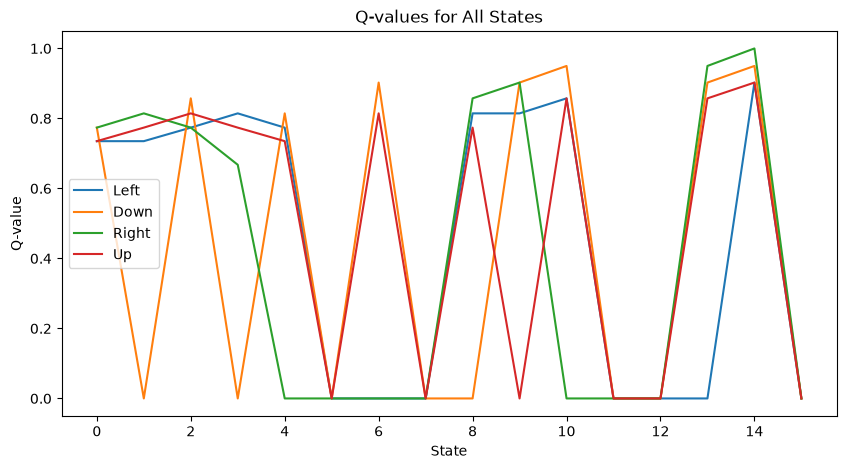

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(q_table)
plt.xlabel("State")
plt.ylabel("Q-value")
plt.title("Q-values for All States")
plt.legend(actions)
plt.show()

In [29]:
max_q_values = np.max(q_table, axis=1)
for state, value in enumerate(max_q_values):
    print("State", state, "->", round(value, 3))

State 0 -> 0.774
State 1 -> 0.815
State 2 -> 0.857
State 3 -> 0.815
State 4 -> 0.815
State 5 -> 0.0
State 6 -> 0.902
State 7 -> 0.0
State 8 -> 0.857
State 9 -> 0.902
State 10 -> 0.95
State 11 -> 0.0
State 12 -> 0.0
State 13 -> 0.95
State 14 -> 1.0
State 15 -> 0.0


In [30]:
for state in range(len(q_table)):
    best_action = np.argmax(q_table[state])
    print("State:", state, "Action:", actions[best_action],
          "Q-value:", round(q_table[state, best_action], 3))

State: 0 Action: Down Q-value: 0.774
State: 1 Action: Right Q-value: 0.815
State: 2 Action: Down Q-value: 0.857
State: 3 Action: Left Q-value: 0.815
State: 4 Action: Down Q-value: 0.815
State: 5 Action: Left Q-value: 0.0
State: 6 Action: Down Q-value: 0.902
State: 7 Action: Left Q-value: 0.0
State: 8 Action: Right Q-value: 0.857
State: 9 Action: Down Q-value: 0.902
State: 10 Action: Down Q-value: 0.95
State: 11 Action: Left Q-value: 0.0
State: 12 Action: Left Q-value: 0.0
State: 13 Action: Right Q-value: 0.95
State: 14 Action: Right Q-value: 1.0
State: 15 Action: Left Q-value: 0.0


In [31]:
success = 0
episodes = 1000

for episode in range(episodes):
    state, _ = env.reset()
    done = False
    while not done:
        action = np.argmax(q_table[state])
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
    success += reward
print("Success Rate:", success / episodes * 100, "%")

Success Rate: 100.0 %


In [32]:
steps = []

for episode in range(100):
    state, _ = env.reset()
    done = False
    count = 0
    while not done:
        action = np.argmax(q_table[state])
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        count += 1
    steps.append(count)
print("Average Steps:", np.mean(steps))

Average Steps: 6.0


In [33]:
policy_grid = np.array([
    actions[np.argmax(q_table[state])][0]
    for state in range(16)
]).reshape(4, 4)

print(policy_grid)

[['D' 'R' 'D' 'L']
 ['D' 'L' 'D' 'L']
 ['R' 'D' 'D' 'L']
 ['L' 'R' 'R' 'L']]


In [34]:
success = 0
for episode in range(20):
    state, _ = env.reset()
    done = False
    while not done:
        action = np.argmax(q_table[state])
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
    success += reward
    print("Episode", episode + 1, "Reward:", reward)
print("Successful Episodes:", int(success))

Episode 1 Reward: 1
Episode 2 Reward: 1
Episode 3 Reward: 1
Episode 4 Reward: 1
Episode 5 Reward: 1
Episode 6 Reward: 1
Episode 7 Reward: 1
Episode 8 Reward: 1
Episode 9 Reward: 1
Episode 10 Reward: 1
Episode 11 Reward: 1
Episode 12 Reward: 1
Episode 13 Reward: 1
Episode 14 Reward: 1
Episode 15 Reward: 1
Episode 16 Reward: 1
Episode 17 Reward: 1
Episode 18 Reward: 1
Episode 19 Reward: 1
Episode 20 Reward: 1
Successful Episodes: 20


In [35]:
rewards = []

for episode in range(100):
    state, _ = env.reset()
    done = False
    total_reward = 0
    while not done:
        action = np.argmax(q_table[state])
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward
    rewards.append(total_reward)
print("Average Reward:", np.mean(rewards))

Average Reward: 1.0


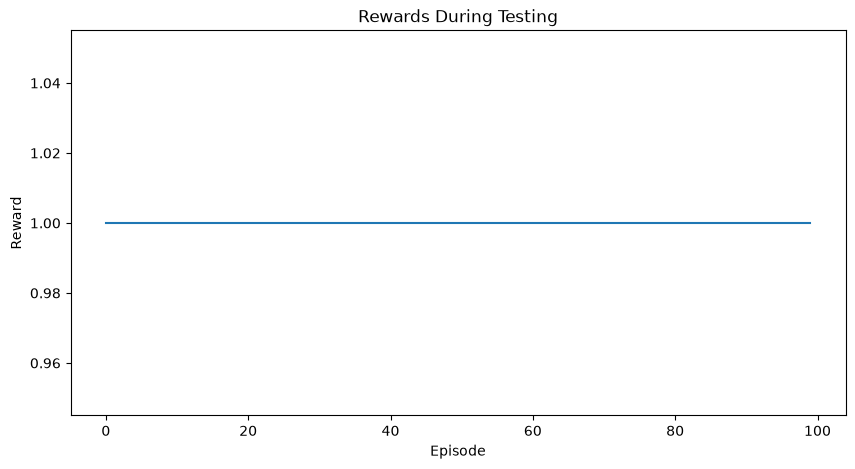

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Rewards During Testing")
plt.show()

In [37]:
success_rate = np.mean(rewards) * 100
average_steps = np.mean(steps)
print("Final Performance")
print("Success Rate:", success_rate, "%")
print("Average Steps:", average_steps)

Final Performance
Success Rate: 100.0 %
Average Steps: 6.0


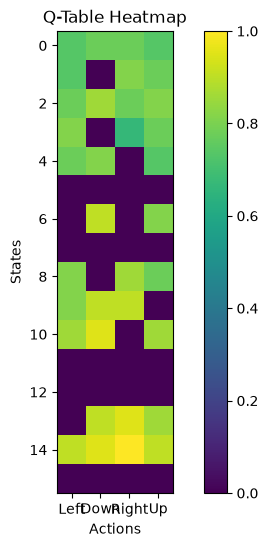

In [38]:
plt.figure(figsize=(8, 6))
plt.imshow(q_table)
plt.colorbar()
plt.xlabel("Actions")
plt.ylabel("States")
plt.xticks(range(4), actions)
plt.title("Q-Table Heatmap")
plt.show()

In [39]:
state = np.unravel_index(np.argmax(q_table), q_table.shape)
print("State:", state[0])
print("Action:", actions[state[1]])
print("Highest Q-value:", q_table[state])

State: 14
Action: Right
Highest Q-value: 1.0


In [40]:
start_state = 0
best_action = np.argmax(q_table[start_state])
print("Starting State:", start_state)
print("Best Action:", actions[best_action])
print("Q-value:", q_table[start_state, best_action])

Starting State: 0
Best Action: Down
Q-value: 0.7737809374999999


In [41]:
state, _ = env.reset()
done = False
path = [state]
while not done:
    action = np.argmax(q_table[state])
    state, reward, terminated, truncated, _ = env.step(action)
    path.append(state)
    done = terminated or truncated
print("Optimal Path:", path)
print("Final Reward:", reward)

Optimal Path: [0, 4, 8, 9, 13, 14, 15]
Final Reward: 1


In [42]:
print("Q-Learning Agent Results")
print("------------------------")
print("Success Rate:", success_rate, "%")
print("Average Steps:", average_steps)
print("Optimal Path:", path)
print("Final Reward:", reward)

Q-Learning Agent Results
------------------------
Success Rate: 100.0 %
Average Steps: 6.0
Optimal Path: [0, 4, 8, 9, 13, 14, 15]
Final Reward: 1
